# Point Percentage Earned Last Year Vs This Year

In [227]:
import os
import pandas as pd

import numpy as np
import requests
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import requests
from matplotlib.offsetbox import OffsetImage
from matplotlib.ticker import PercentFormatter


from matplotlib.ticker import PercentFormatter
# from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.image as mpimg
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

from PIL import Image


# path to TEMP folder
temp_folder = os.path.join(os.getcwd(), '..', '..', 'TEMP')
# Data folder
data_folder = os.path.join(os.getcwd(), '..', '..', 'data')
# Print List of files in data folder
print(os.listdir(data_folder))
# path to Roster folder in data
roster_folder = os.path.join(os.getcwd(), data_folder, 'player_info')
# path to School Info folder in data
school_info_folder = os.path.join(os.getcwd(), data_folder, 'school_info')
# Image folder
img_folder = os.path.join(os.getcwd(), '..', '..', 'images')
# Logo folder
logo_folder = os.path.join(os.getcwd(), '..', '..', 'images', 'logos')
# Print List of files in logo folder
print(os.listdir(logo_folder))


################################################################################
roster_file = os.path.join(roster_folder, 'roster_10_30_25.csv') # PATH TO THE ROSTER FILE
roster_df = pd.read_csv(roster_file) # read as dataframe

########## HOTFIX FOR MISSING TEAM NAMES IN ROSTER FILE
### Change team name from RPI to Rensselaer
# roster_df.head(5)
roster_df['Current Team'] = roster_df['Current Team'].replace('RPI', 'Rensselaer')
print(roster_df.columns)

# Path to school info table (csv)
school_info_file = os.path.join(school_info_folder, 'arena_school_info.csv')
school_info_df = pd.read_csv(school_info_file)



['db', 'Exo_2', 'full_roster_location_summary_geocoded_2025.csv', 'player_info', 'school_info', 'tables', 'vault']
['afa.png', 'aic.png', 'aka.png', 'akf.png', 'arm.png', 'asu.png', 'asu_orig.png', 'aug.png', 'bc_.png', 'ben.png', 'bgs.png', 'bmj.png', 'brn.png', 'bu_.png', 'cc_.png', 'clg.png', 'clk.png', 'cns.png', 'conference', 'cor.png', 'dar.png', 'den.png', 'fsu.png', 'har.png', 'hcr.png', 'lin.png', 'liu.png', 'lss.png', 'mer.png', 'mia.png', 'mic.png', 'min.png', 'mnd.png', 'mne.png', 'mns.png', 'mrc.png', 'msu.png', 'mtu.png', 'ndk.png', 'ndm.png', 'nia.png', 'nmu.png', 'noe.png', 'osu.png', 'prv.png', 'prv_chn.png', 'psu.png', 'qui.png', 'ren.png', 'rit.png', 'rmu.png', 'sac.png', 'stc.png', 'stl.png', 'stn.png', 'stt.png', 'uma.png', 'uml.png', 'unh.png', 'uni.png', 'uno.png', 'ver.png', 'wis.png', 'wmu.png', 'yal.png', '_con.png', '_prn.png']
Index(['Current Team', 'Last_Name', 'First_Name', 'No', 'Position', 'Yr', 'Ht',
       'Wt', 'DOB', 'Hometown', 'Height_Inches', 'Dra

In [228]:
# school_logo_df.head(3)

### Collect Game Results for Transformation

In [229]:
current_year_url = 'https://www.collegehockeynews.com/schedules/?season=20252026'
season = '2025-2026'
season_start_year = 2025

# current_year_url = 'https://www.collegehockeynews.com/schedules/?season=20242025'
# season = '2024-2025'
# season_start_year = 2024

In [230]:
# ## Table to Last season's results data
# ### Eventually would like to get results with SQL querry from database but
# ### for now will just grab from College Hockey News website

# ## Functions
# ### Parse the current season schedule / results page

# def parse_current_season(url):
#         # Initialize variables
#     current_date = None
#     current_conference = None
#     game_notes = None

#     # Initialize an empty list to hold the data
#     data = []

#     # Parse the page with BeautifulSoup
#     # Get the page with requests
#     response = requests.get(url)

#     # Create a BeautifulSoup object
#     soup = BeautifulSoup(response.text, 'html.parser')

#     # select the table or tables
#     tables = soup.find_all('table')

#     rows = soup.find_all('tr')

#     # Loop through each row to find relevant information
#     for row in rows:
#         # Check for date row
#         if row.get('class') == ['stats-section']:
#             current_date = row.find('td').text.strip()
#         # Check for conference row
#         elif row.get('class') == ['sked-header']:
#             current_conference = row.find('td').text.strip()
#         # Check for game notes
#         elif len(row.find_all('td')) == 2:
#             game_notes = row.find_all('td')[1].text.strip()
#         # Process rows with game data
#         elif row.get('valign') == 'top':
#             cells = row.find_all('td')
#             if len(cells) >= 9:
#                 home_team = cells[0].text.strip()
#                 # Remove any hyphens from the team name
#                 home_team = home_team.replace('-', ' ')
#                 home_team_link = cells[0].find('a')['href'] if cells[0].find('a') else None
#                 home_score = cells[1].text.strip()
#                 away_team = cells[3].text.strip()
#                 away_team_link = cells[3].find('a')['href'] if cells[3].find('a') else None
#                 away_score = cells[4].text.strip()
#                 ot = cells[5].text.strip()
#                 box_link = cells[7].find('a')['href'] if cells[7].find('a') else None
#                 metrics_link = cells[8].find('a')['href'] if cells[8].find('a') else None
#                 # Capture Game Notes
#                 game_notes_cell = cells[-1].find('small')
#                 game_notes = game_notes_cell.text.strip() if game_notes_cell else None

#                 # Append data to the list
#                 data.append([current_date, current_conference, game_notes, home_team, home_team_link, home_score, away_team, away_team_link, away_score, ot, box_link, metrics_link])
#                 game_notes = None  # Reset game notes for the next row
#     return data

# ## call the function
# data = parse_current_season(current_year_url)


# # Create a dataframe from the list

# columns = ['Date', 'Conference', 'Game_Notes',  'Away_Team', 'Away_Team_Link', 'Away_Score', 'Home_Team', 'Home_Team_Link', 'Home_Score','OT', 'Box_Link', 'Metrics_Link']
# df = pd.DataFrame(data, columns=columns)
            
# ## Extract the day of the week from the date and save in new column
# df['Day'] = pd.to_datetime(df['Date']).dt.day_name()
# # remove day of the week from date
# # format data column as YYYY-MM-DD
# df['Date'] = pd.to_datetime(df['Date']).dt.strftime('%Y-%m-%d')

# ### Create a new column for the game ID
# ## Game ID will be a combination of the date and abbreviated team names

# # Loop to abbreviate the team names
# for row in df.itertuples():
#     home_team = row.Home_Team
#     away_team = row.Away_Team
#     home_team_abbr = home_team.split(' ')[-1]
#     away_team_abbr = away_team.split(' ')[-1]
#     # Remove any hyphens from the team name if there are any
#     home_team_abbr = home_team_abbr.replace('-', ' ')
#     away_team_abbr = away_team_abbr.replace('-', ' ')
#     game_id = f'{row.Date}-{home_team_abbr}-{away_team_abbr}'
#     df.loc[row.Index, 'Game_ID'] = game_id

# # Create a new column for the game ID
# df['Game_ID'] = df['Game_ID'].str.replace(',', '')

# # Remove any hyphens from the team names if any
# df['Home_Team'] = df['Home_Team'].str.replace('-', ' ')
# df['Away_Team'] = df['Away_Team'].str.replace('-', ' ')

# # Apply the function to the DataFrame
# df['Game_ID'] = df.apply(lambda row: f'{row.Date}-{row.Home_Team}-{row.Away_Team}', axis=1)

# ## Filter out games that have not been played yet
# df = df[df['Home_Score'] != '']

# # Replace Nan values in metrics column with empty string
# df['Metrics_Link'] = df['Metrics_Link'].fillna('')

In [231]:
# df.info()

# ## SAVE THE DATAFRAME TO A CSV FILE IN THE TEMP FOLDER
# output_file = os.path.join(temp_folder, f'current_season_results_{season_start_year}_{season_start_year +1}.csv')
# df.to_csv(output_file, index=False)

# Filtering and Transforming Results Tables
- currently uses local static csv files for game results

In [232]:
### Set the cutoff date (month, day)
cutoff_month = 10
cutoff_day = 30

## Load the first season in comparison from temp folder
input_file_1 = os.path.join(temp_folder, f'current_season_results_2024_2025.csv')
df1 = pd.read_csv(input_file_1)
# df1.info()

input_file_2 = os.path.join(temp_folder, f'current_season_results_2025_2026.csv')
df2 = pd.read_csv(input_file_2)
# df2.info()

# Drop any rows with unplayed games (where Home_Score or Away_Score is missing)
df1 = df1.dropna(subset=['Home_Score', 'Away_Score'])
df2 = df2.dropna(subset=['Home_Score', 'Away_Score'])

## Replace 'RPI' with 'Rensselaer' in both dataframes
df1['Home_Team'] = df1['Home_Team'].replace('RPI', 'Rensselaer')
df1['Away_Team'] = df1['Away_Team'].replace('RPI', 'Rensselaer')
df2['Home_Team'] = df2['Home_Team'].replace('RPI', 'Rensselaer')
df2['Away_Team'] = df2['Away_Team'].replace('RPI', 'Rensselaer')

# Strip punctuation from team names in both dataframes
df1['Home_Team'] = df1['Home_Team'].str.replace('[^\w\s]', '', regex=True)
df1['Away_Team'] = df1['Away_Team'].str.replace('[^\w\s]', '', regex=True)
df2['Home_Team'] = df2['Home_Team'].str.replace('[^\w\s]', '', regex=True)
df2['Away_Team'] = df2['Away_Team'].str.replace('[^\w\s]', '', regex=True)

# Length of both dataframes before and after filtering Exhibition games
print('________________________________')
print('Length of both dataframes before and after filtering Exhibition games:')
print('________________________________')
print(f'Length of df1 before filtering: {len(df1)}')
print(f'Length of df2 before filtering: {len(df2)}\n________________________________')

# Filter out any exhibition games from both dataframes
df1 = df1[~df1['Conference'].str.contains('Exhibition')]
df2 = df2[~df2['Conference'].str.contains('Exhibition')]

print(f'Length of df1 after filtering: {len(df1)}')
print(f'Length of df2 after filtering: {len(df2)}\n________________________________')



________________________________
Length of both dataframes before and after filtering Exhibition games:
________________________________
Length of df1 before filtering: 1230
Length of df2 before filtering: 211
________________________________
Length of df1 after filtering: 1171
Length of df2 after filtering: 179
________________________________


<>:25: SyntaxWarning: invalid escape sequence '\w'
<>:26: SyntaxWarning: invalid escape sequence '\w'
<>:27: SyntaxWarning: invalid escape sequence '\w'
<>:28: SyntaxWarning: invalid escape sequence '\w'
<>:25: SyntaxWarning: invalid escape sequence '\w'
<>:26: SyntaxWarning: invalid escape sequence '\w'
<>:27: SyntaxWarning: invalid escape sequence '\w'
<>:28: SyntaxWarning: invalid escape sequence '\w'
C:\Users\jbanc\AppData\Local\Temp\ipykernel_7804\676360793.py:25: SyntaxWarning: invalid escape sequence '\w'
  df1['Home_Team'] = df1['Home_Team'].str.replace('[^\w\s]', '', regex=True)
C:\Users\jbanc\AppData\Local\Temp\ipykernel_7804\676360793.py:26: SyntaxWarning: invalid escape sequence '\w'
  df1['Away_Team'] = df1['Away_Team'].str.replace('[^\w\s]', '', regex=True)
C:\Users\jbanc\AppData\Local\Temp\ipykernel_7804\676360793.py:27: SyntaxWarning: invalid escape sequence '\w'
  df2['Home_Team'] = df2['Home_Team'].str.replace('[^\w\s]', '', regex=True)
C:\Users\jbanc\AppData\Local\Te

In [233]:
## Make Sure Rensselaer is in both dataframes as either Home Team or Away Team
df1[df1['Home_Team'] == 'Rensselaer'].head()
df2[df2['Home_Team'] == 'Rensselaer'].head()
# df1[df1['Away_Team'] == 'Rensselaer'].head()
# df2[df2['Away_Team'] == 'Rensselaer'].head()

,Date,Conference,Game_Notes,Away_Team,Away_Team_Link,Away_Score,Home_Team,Home_Team_Link,Home_Score,OT,Box_Link,Metrics_Link,Day,Game_ID
66,2025-10-10,Non-Conference,NaN,Miami,/reports/team/Miami/30,5,Rensselaer,/reports/team/RPI/48,3,NaN,/box/final/20251010/mia/ren/,/box/metrics.php?gd=110574,Friday,2025-10-10-RPI-Miami
85,2025-10-11,Non-Conference,NaN,Miami,/reports/team/Miami/30,5,Rensselaer,/reports/team/RPI/48,0,NaN,/box/final/20251011/mia/ren/,/box/metrics.php?gd=110575,Saturday,2025-10-11-RPI-Miami
113,2025-10-17,Non-Conference,NaN,Boston College,/reports/team/Boston-College/9,5,Rensselaer,/reports/team/RPI/48,1,NaN,/box/final/20251017/bc_/ren/,/box/metrics.php?gd=111074,Friday,2025-10-17-RPI-Boston College
132,2025-10-18,Non-Conference,NaN,Providence,/reports/team/Providence/46,5,Rensselaer,/reports/team/RPI/48,1,NaN,/box/final/20251018/prv/ren/,/box/metrics.php?gd=111075,Saturday,2025-10-18-RPI-Providence


In [234]:
import pandas as pd
from datetime import date

def _normalize_dates(df: pd.DataFrame, date_col: str) -> pd.DataFrame:
    out = df.copy()
    out[date_col] = pd.to_datetime(out[date_col], errors="coerce")
    return out.dropna(subset=[date_col])

def _infer_season_start_year_for_df(df: pd.DataFrame, date_col: str, season_start_month: int = 8) -> int:
    """
    Infer college-hockey season start year for this dataframe.
    Rule: if a game date is Aug–Dec -> season_start_year = that year
          if Jan–Jul -> season_start_year = that year - 1
    We expect one season per df; if mixed, take the mode (most common).
    """
    s = df[date_col].dt
    inferred = (s.year.where(s.month >= season_start_month, s.year - 1)).astype(int)
    # Use the most common season start year (handles edge cases if a stray row slips in)
    return int(inferred.mode().iloc[0])

def _filter_df_through_month_day(
    df: pd.DataFrame,
    month: int,
    day: int,
    date_col: str = "Date",
    keep_only_played: bool = True,
    season_start_month: int = 8,
    season_start_day: int = 1,
) -> pd.DataFrame:
    """
    Filter a dataframe to include games from the inferred season start (Aug 1 by default)
    through the specified month/day of that season.

    Examples:
      - If df is 2025-26 season and you pass (11, 15), you get Aug 1, 2025 .. Nov 15, 2025
      - If df is 2025-26 season and you pass (2, 10),  you get Aug 1, 2025 .. Feb 10, 2026
    """
    if date_col not in df.columns:
        raise ValueError(f"'{date_col}' column not found")

    out = _normalize_dates(df, date_col)
    if out.empty:
        return out

    # Optionally keep only games with numeric scores (played games)
    if keep_only_played and {"Home_Score", "Away_Score"}.issubset(out.columns):
        out = out[
            out["Home_Score"].astype(str).str.fullmatch(r"\d+") &
            out["Away_Score"].astype(str).str.fullmatch(r"\d+")
        ].copy()

    if out.empty:
        return out

    # Infer season start year from the df itself
    season_start_year = _infer_season_start_year_for_df(out, date_col, season_start_month=season_start_month)

    # Build bounds and cutoff
    season_start = pd.Timestamp(date(season_start_year, season_start_month, season_start_day))
    season_end   = pd.Timestamp(date(season_start_year + 1, season_start_month - 1 if season_start_month > 1 else 12,
                                     31 if season_start_month > 1 else 31))
    # Correct season_end for typical Aug 1 start -> Jul 31 end
    if season_start_month == 8 and season_start_day == 1:
        season_end = pd.Timestamp(date(season_start_year + 1, 7, 31))

    cutoff_year = season_start_year if month >= season_start_month else (season_start_year + 1)
    cutoff = pd.Timestamp(date(cutoff_year, month, day))

    # Clamp cutoff to [season_start, season_end]
    if cutoff < season_start:
        cutoff = season_start
    if cutoff > season_end:
        cutoff = season_end

    mask = (out[date_col] >= season_start) & (out[date_col] <= cutoff)
    return out.loc[mask].reset_index(drop=True)

def filter_two_seasons_through_month_day(
    df1: pd.DataFrame,
    df2: pd.DataFrame,
    month: int,
    day: int,
    date_col: str = "Date",
    keep_only_played: bool = True,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Convenience wrapper: infer each df's season and filter each to the same month/day cutoff
    within its own season.
    """
    f1 = _filter_df_through_month_day(
        df1, month, day, date_col=date_col, keep_only_played=keep_only_played
    )
    f2 = _filter_df_through_month_day(
        df2, month, day, date_col=date_col, keep_only_played=keep_only_played
    )
    return f1, f2

# say df1 is 2025-26 and df2 is 2023-24 (doesn’t matter—you don’t tell me the season)
df1_cut, df2_cut = filter_two_seasons_through_month_day(df1, df2, month=10, day=30)

print(len(df1_cut), len(df2_cut))
# both are filtered from their own Aug 1 season start through Oct 30 of that same season



175 179


### Calculate Win Lose Tie Record

In [235]:
def compute_team_records(results_df: pd.DataFrame,
                         home_col: str = "Home_Team",
                         away_col: str = "Away_Team",
                         home_score_col: str = "Home_Score",
                         away_score_col: str = "Away_Score",
                         ot_col: str = "OT") -> pd.DataFrame:
    """
    Compute cumulative record per team:
      - Wins, Losses include BOTH regulation and OT/SO outcomes
      - Overtime_W, Overtime_L count only games with an OT/SO marker
      - Ties where scores are equal (official record tie). Shootout outcomes
        in NCAA are typically recorded as ties in the W-L-T column.
    Returns a DataFrame with columns:
      ['Team','Wins','Losses','Overtime_W','Overtime_L','Ties']
    """
    df = results_df.copy()

    # Ensure score columns are numeric; drop any non-played rows gracefully
    def _to_int_safe(s):
        s = s.astype(str).str.extract(r"(\d+)")[0]
        return pd.to_numeric(s, errors="coerce")

    if home_score_col in df.columns and away_score_col in df.columns:
        df[home_score_col] = _to_int_safe(df[home_score_col])
        df[away_score_col] = _to_int_safe(df[away_score_col])
        df = df.dropna(subset=[home_score_col, away_score_col])
    else:
        raise ValueError("Expected score columns not found in DataFrame.")

    # Normalize OT column to detect any overtime/shootout indicator
    if ot_col in df.columns:
        ot_series = df[ot_col].fillna("").astype(str).str.lower().str.strip()
    else:
        ot_series = pd.Series([""] * len(df))

    # Determine outcomes
    home_win = df[home_score_col] > df[away_score_col]
    away_win = df[home_score_col] < df[away_score_col]
    tie_game = df[home_score_col] == df[away_score_col]

    # OT flag if the cell contains 'ot' or 'so' (handles '2ot', 'ot', 'so', etc.)
    ot_flag = ot_series.str.contains(r"\bot\b|\bso\b|\d+ot", regex=True)

    # Build per-game, per-team tallies
    home_rows = pd.DataFrame({
        "Team": df[home_col].astype(str),
        "Win": home_win.astype(int),
        "Loss": away_win.astype(int),
        "Tie": tie_game.astype(int),
        "OT_W": (home_win & ot_flag).astype(int),
        "OT_L": (away_win & ot_flag).astype(int),
    })

    away_rows = pd.DataFrame({
        "Team": df[away_col].astype(str),
        "Win": away_win.astype(int),
        "Loss": home_win.astype(int),
        "Tie": tie_game.astype(int),
        "OT_W": (away_win & ot_flag).astype(int),
        "OT_L": (home_win & ot_flag).astype(int),
    })

    tallies = pd.concat([home_rows, away_rows], ignore_index=True)

    agg = (tallies.groupby("Team", as_index=False)
                  .agg(Wins=("Win", "sum"),
                       Losses=("Loss", "sum"),
                       Overtime_W=("OT_W", "sum"),
                       Overtime_L=("OT_L", "sum"),
                       Ties=("Tie", "sum"))
           .sort_values(["Wins", "Losses"], ascending=[False, True])
           .reset_index(drop=True))

    # Ensure integer dtype
    for c in ["Wins", "Losses", "Overtime_W", "Overtime_L", "Ties"]:
        agg[c] = agg[c].astype(int)

    return agg

year_one_records = compute_team_records(df1_cut)
year_two_records = compute_team_records(df2_cut)

In [236]:
# Look for Rensselaer in both dataframes
print(year_one_records[year_one_records['Team'] == 'Rensselaer'])
print(year_two_records[year_two_records['Team'] == 'Rensselaer'])

          Team  Wins  Losses  Overtime_W  Overtime_L  Ties
39  Rensselaer     2       3           0           1     1
          Team  Wins  Losses  Overtime_W  Overtime_L  Ties
54  Rensselaer     0       6           0           0     0


#### Calculate Points Percentage (points earned / total possible points)

In [237]:
## Does both a Simple 2 pt per game system: 2 for win, 1 for tie, 0 for loss
## and more complex 3 ptsystem based on the NHL and Conference points system 
## Unfortunately the data set I have does not include shootout wins/losses
## Therefore we will just fo Regulation win:3, OT/SO win:2, OT/SO loss:1, Tie:1, Regulation loss:0

def calculate_points_percentage_2pt_system(record_df: pd.DataFrame) -> pd.DataFrame:
    df = record_df.copy()
    # Calculate total games
    df['Total_Games'] = df['Wins'] + df['Losses'] + df['Ties']
    # Calculate total points earned
    df['Points_Earned_2pt_sys'] = (df['Wins'] * 2) + (df['Ties'] * 1)
    # Calculate total possible points
    df['Total_Possible_Points_2pt_sys'] = df['Total_Games'] * 2

    # Calculate total points earned using 3 Pt system
    df['Points_Earned_3pt_sys'] = ((df['Wins'] - df['Overtime_W']) * 3) + (df['Overtime_W'] * 2) + (df['Overtime_L'] * 1) + (df['Ties'] * 1)

    # Calculate total possible points
    df['Total_Possible_Points_3pt_sys'] = df['Total_Games'] * 3

    # Calculate points percentage
    df['Points_Percentage_2pt_sys'] = df['Points_Earned_2pt_sys'] / df['Total_Possible_Points_2pt_sys']
    df['Points_Percentage_3pt_sys'] = df['Points_Earned_3pt_sys'] / df['Total_Possible_Points_3pt_sys']

    return df

year_one_records = calculate_points_percentage_2pt_system(year_one_records)
year_two_records = calculate_points_percentage_2pt_system(year_two_records)
year_one_records.head()
year_two_records.head()

,Team,Wins,Losses,Overtime_W,Overtime_L,Ties,Total_Games,Points_Earned_2pt_sys,Total_Possible_Points_2pt_sys,Points_Earned_3pt_sys,Total_Possible_Points_3pt_sys,Points_Percentage_2pt_sys,Points_Percentage_3pt_sys
0,Penn State,8,1,1,0,0,9,16,18,23,27,0.888889,0.851852
1,Michigan,7,1,0,0,0,8,14,16,21,24,0.875000,0.875000
2,Minnesota Duluth,7,1,0,0,0,8,14,16,21,24,0.875000,0.875000
3,Miami,6,0,2,0,0,6,12,12,16,18,1.000000,0.888889
4,Wisconsin,5,0,0,0,2,7,12,14,17,21,0.857143,0.809524


In [238]:
### Merge the two dataframes on Team name to compare year over year
comparison_df = pd.merge(year_one_records, year_two_records, on='Team', suffixes=('_Year1', '_Year2'))

# Only keep relevent columns drop wins losses ties ot_w ot_l total games
comparison_df = comparison_df[['Team', 'Points_Percentage_2pt_sys_Year1', 'Points_Percentage_2pt_sys_Year2',
                                'Points_Earned_2pt_sys_Year1', 'Total_Possible_Points_2pt_sys_Year1',
                                'Points_Earned_2pt_sys_Year2', 'Total_Possible_Points_2pt_sys_Year2',
                               'Points_Percentage_3pt_sys_Year1', 'Points_Percentage_3pt_sys_Year2',
                                'Points_Earned_3pt_sys_Year1', 'Total_Possible_Points_3pt_sys_Year1',
                                'Points_Earned_3pt_sys_Year2', 'Total_Possible_Points_3pt_sys_Year2']]

comparison_df.head()



,Team,Points_Percentage_2pt_sys_Year1,Points_Percentage_2pt_sys_Year2,Points_Earned_2pt_sys_Year1,Total_Possible_Points_2pt_sys_Year1,Points_Earned_2pt_sys_Year2,Total_Possible_Points_2pt_sys_Year2,Points_Percentage_3pt_sys_Year1,Points_Percentage_3pt_sys_Year2,Points_Earned_3pt_sys_Year1,Total_Possible_Points_3pt_sys_Year1,Points_Earned_3pt_sys_Year2,Total_Possible_Points_3pt_sys_Year2
0,Denver,1.000000,0.583333,12,12,7,12,1.000000,0.555556,18,18,10,18
1,St Cloud State,0.857143,0.714286,12,14,10,14,0.857143,0.761905,18,21,16,21
2,Union,0.857143,0.900000,12,14,9,10,0.809524,0.866667,17,21,13,15
3,Ohio State,0.916667,0.571429,11,12,8,14,0.833333,0.619048,15,18,13,21
4,Michigan State,0.833333,0.833333,10,12,10,12,0.777778,0.777778,14,18,14,18


In [239]:
# Check for Rensselaer
print(comparison_df[comparison_df['Team'] == 'Rensselaer'])

          Team  Points_Percentage_2pt_sys_Year1  \
39  Rensselaer                         0.416667   

    Points_Percentage_2pt_sys_Year2  Points_Earned_2pt_sys_Year1  \
39                              0.0                            5   

    Total_Possible_Points_2pt_sys_Year1  Points_Earned_2pt_sys_Year2  \
39                                   12                            0   

    Total_Possible_Points_2pt_sys_Year2  Points_Percentage_3pt_sys_Year1  \
39                                   12                         0.444444   

    Points_Percentage_3pt_sys_Year2  Points_Earned_3pt_sys_Year1  \
39                              0.0                            8   

    Total_Possible_Points_3pt_sys_Year1  Points_Earned_3pt_sys_Year2  \
39                                   18                            0   

    Total_Possible_Points_3pt_sys_Year2  
39                                   18  


## Start Visualization Code

In [240]:
### Helper Functions

## Use the school info to get hex codes, logo files, and other info



# Remove punctuation from the school names (dashes with spaces, . and ' with nothing)
school_info_df['Team'] = school_info_df['Team'].str.replace('-', ' ')
school_info_df['Team'] = school_info_df['Team'].str.replace('.', '')
school_info_df['Team'] = school_info_df['Team'].str.replace("'", '')
# school_info_df.head() # Check the data

# # Create a color dictionary with just the primary (hex1) and secondary (hex2) colors from the school info
# Team: hex1, hex2
# Drop unused columns
school_color_df = school_info_df[['Team', 'hex1', 'hex2']]
color_mapping = school_color_df.set_index('Team').T.to_dict('list')
# color_mapping # Show dictionary
## MAY NEED TO ADD LEADING/ TRAILING zeros to the hex codes

# Create a dictionary of school logos
# Team: logo + '.png'
# Drop unused columns
school_logo_df = school_info_df[['Team', 'logo_abv']]
school_logo_df['logo_abv'] = school_logo_df['logo_abv'] + '.png'
logo_mapping = school_logo_df.set_index('Team')['logo_abv'].to_dict()
# logo_mapping # Check the dictionary






C:\Users\jbanc\AppData\Local\Temp\ipykernel_7804\611924253.py:17: UserWarning: DataFrame columns are not unique, some columns will be omitted.
  color_mapping = school_color_df.set_index('Team').T.to_dict('list')
C:\Users\jbanc\AppData\Local\Temp\ipykernel_7804\611924253.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  school_logo_df['logo_abv'] = school_logo_df['logo_abv'] + '.png'


In [241]:
## ORIGINAL CODE FROM OLD BOOK
def add_logos_to_plot(data_df, x_col, y_col, logo_mapping, logo_folder, ax, teams_in_region):
    # Plot logos for specific teams
    for team in teams_in_region:
        team_data = data_df[data_df['Team'] == team]
        if not team_data.empty:
            x = team_data[x_col].values[0]
            y = team_data[y_col].values[0]
            logo_path = os.path.join(logo_folder, logo_mapping.get(team, ""))
            if logo_path:
                try:
                    logo_img = plt.imread(logo_path)
                    imagebox = OffsetImage(logo_img, zoom=0.15)  # Adjust zoom as needed
                    ab = AnnotationBbox(imagebox, (x, y), frameon=False, xybox=(10, 20), boxcoords="offset points", pad=0)
                    ax.add_artist(ab)  # Apply the ax here as the artist is being added to ax
                except Exception as e:
                    print(f"Error adding logo for {team}: {e}")




In [242]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from matplotlib.offsetbox import OffsetImage, AnnotationBbox


### REWRITTEN BY CHATGPT 10/31/25

# Build normalized logo mapping
school_logo_df = school_info_df[['Team', 'logo_abv']].copy()
school_logo_df['Team_norm'] = (
    school_logo_df['Team'].astype(str)
    .str.replace('-', ' ', regex=False)
    .str.replace('.', '', regex=False)
    .str.replace("'", '', regex=False)
    .str.strip()
)

# append '.png' if missing (avoid double '.png')
logo_files = school_logo_df['logo_abv'].astype(str).str.strip()
logo_files = logo_files.mask(logo_files.str.lower().str.endswith('.png') == False,
                             logo_files + '.png')
logo_mapping = dict(zip(school_logo_df['Team_norm'], logo_files))

def add_logos_to_plot(data_df, x_col, y_col, logo_mapping, logo_folder, ax, teams_in_region, zoom=0.15):
    # normalize a copy of the data's Team the same way you normalized school_info_df
    d = data_df.copy()
    d['Team_norm'] = (
        d['Team'].astype(str)
        .str.replace('-', ' ', regex=False)
        .str.replace('.', '', regex=False)
        .str.replace("'", '', regex=False)
        .str.strip()
    )

    # also normalize the requested highlight names before lookup
    def norm_name(t):
        return (str(t)
                .replace('-', ' ')
                .replace('.', '')
                .replace("'", '')
                .strip())

    for team in teams_in_region:
        t_norm = norm_name(team)
        team_row = d[d['Team_norm'] == t_norm]
        if team_row.empty:
            # helpful debug
            print(f"[logo] Team not found in data after normalization: {team}")
            continue

        x = team_row[x_col].values[0]
        y = team_row[y_col].values[0]

        # mapping uses normalized Team keys too (see B)
        logo_file = logo_mapping.get(t_norm, "")
        if not logo_file:
            print(f"[logo] No logo mapping for team: {team} (normalized: {t_norm})")
            continue

        logo_path = os.path.join(logo_folder, logo_file)
        if not os.path.exists(logo_path):
            print(f"[logo] Logo file not found for {team}: {logo_path}")
            continue

        try:
            logo_img = plt.imread(logo_path)
            imagebox = OffsetImage(logo_img, zoom=zoom)
            ab = AnnotationBbox(imagebox, (x, y), frameon=False, xybox=(0, 0),
                                boxcoords="offset points", pad=0, zorder=10)
            ax.add_artist(ab)
        except Exception as e:
            print(f"[logo] Error adding logo for {team}: {e}")


In [252]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

def add_logos_to_plot(data_df, x_col, y_col, logo_mapping, logo_folder, ax, teams_in_region, zoom=0.17):
    """Uses your existing logic to place logos on selected teams."""
    for team in teams_in_region:
        team_data = data_df[data_df['Team'] == team]
        if not team_data.empty:
            x = team_data[x_col].values[0]
            y = team_data[y_col].values[0]
            logo_file = logo_mapping.get(team, "")
            if not logo_file:
                continue
            logo_path = os.path.join(logo_folder, logo_file)
            if logo_path and os.path.exists(logo_path):
                try:
                    logo_img = plt.imread(logo_path)
                    imagebox = OffsetImage(logo_img, zoom=zoom)
                    ab = AnnotationBbox(imagebox, (x, y), frameon=False, xybox=(0, 0),
                                        boxcoords="offset points", pad=0)
                    ax.add_artist(ab)
                except Exception as e:
                    print(f"Error adding logo for {team}: {e}")

def create_points_pct_scatter(
    df: pd.DataFrame,
    year_one_name: str,
    year_two_name: str,
    point_system: int = 2,
    highlight_teams: list | None = None,
    logo_mapping: dict | None = None,
    logo_folder: str | None = None,
    title: str | None = None,
    output_path: str | None = None
) -> str:
    """
    Build the year-vs-year Points% scatter with league-average guide lines and a 45° reference line.

    Required df columns:
      - For 2-pt: Points_Percentage_2pt_sys_Year1, Points_Percentage_2pt_sys_Year2
      - For 3-pt: Points_Percentage_3pt_sys_Year1, Points_Percentage_3pt_sys_Year2
      - Team

    Returns the saved PNG path.
    """
    if point_system not in (2, 3):
        raise ValueError("point_system must be 2 or 3")

    ps = f"{point_system}pt_sys"
    x_col = f"Points_Percentage_{ps}_Year1"
    y_col = f"Points_Percentage_{ps}_Year2"
    for col in [x_col, y_col, "Team"]:
        if col not in df.columns:
            raise ValueError(f"Missing column: {col}")

    work = df.copy()

    fig, ax = plt.subplots(figsize=(9, 7))

    # scatter
    ax.scatter(work[x_col], work[y_col], alpha=0.75)

    # league averages
    x_avg = work[x_col].mean()
    y_avg = work[y_col].mean()
    ax.axvline(x_avg, linestyle="--", linewidth=1)
    ax.axhline(y_avg, linestyle="--", linewidth=1)

    # 45° reference line (y=x) within plot limits
    xmin, xmax = work[x_col].min(), work[x_col].max()
    ymin, ymax = work[y_col].min(), work[y_col].max()
    pad = 0.02
    xmin, xmax = max(0, xmin - pad), min(1, xmax + pad)
    ymin, ymax = max(0, ymin - pad), min(1, ymax + pad)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    lo, hi = max(xmin, ymin), min(xmax, ymax)
    ax.plot([lo, hi], [lo, hi], linewidth=1)

    # formatting
    ax.xaxis.set_major_formatter(PercentFormatter(1.0))
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set_xlabel(f"{year_one_name} Point's Percentage")
    ax.set_ylabel(f"{year_two_name} Point's Percentage")
    ax.set_title(title or f"Team Points Over Possible Points ({point_system}-Point System)")
    fig.tight_layout()

    # optional logos
    if highlight_teams and logo_mapping and logo_folder:
        add_logos_to_plot(work, x_col, y_col, logo_mapping, logo_folder, ax, highlight_teams, zoom=0.12)

        # === quadrant annotations (corner style like example) ===
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    xmid, ymid = x_avg, y_avg
    dx = (xmax - xmin) * 0.52  # how far toward the sides
    dy = (ymax - ymin) * 0.42  # how far toward the top/bottom

    # Top-Left — Moved Above Average
    ax.text(xmid - (0.8 * dx), ymid + dy,
            "Moved Above\nAverage",
            ha='left', va='top',
            fontsize=20, fontweight='bold',
            color='#6BBF59', alpha=0.35)

    # Top-Right — Stayed Above Average
    ax.text(xmid + dx, ymid + dy,
            "Stayed Above\nAverage",
            ha='right', va='top',
            fontsize=20, fontweight='bold',
            color='#5E837D', alpha=0.35)

    # Bottom-Left — Stayed Below Average
    ax.text(xmid - (0.8 * dx), ymin + 0.05,
            "Stayed Below\nAverage",
            ha='left', va='bottom',
            fontsize=20, fontweight='bold',
            color='#8C8C8C', alpha=0.35)

    # Bottom-Right — Moved Below Average
    ax.text(xmid + dx, ymin + 0.05,
            "Moved Below\nAverage",
            ha='right', va='bottom',
            fontsize=20, fontweight='bold',
            color='#B35C5C', alpha=0.35)



    # save
    if output_path is None:
        safe_y1 = str(year_one_name).replace("/", "-").replace(" ", "_")
        safe_y2 = str(year_two_name).replace("/", "-").replace(" ", "_")
        output_path = f"points_pct_scatter_{safe_y1}_vs_{safe_y2}_{point_system}pt.png"

    # Display the image

    plt.show()

    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.close(fig)
    return output_path


#### Team Group Lists

In [253]:
# create a list of all teams from the comparison dataframe
all_teams = comparison_df['Team'].tolist()

conference_teams_mens = {
    'Atlantic': ['Air Force', 'Army', 'Bentley', 'Canisius', 'Holy Cross', 'Mercyhurst', 
                 'Niagara', 'RIT', 'Robert Morris', 'Sacred Heart'],
    'Big Ten': ['Michigan', 'Michigan State', 'Minnesota', 'Notre Dame', 'Ohio State', 'Penn State', 'Wisconsin'],
    'CCHA': ['Augustana', 'Bemidji State', 'Bowling Green', 'Ferris State', 'Lake Superior', 'Michigan Tech', 
             'Minnesota State', 'Northern Michigan', 'St Thomas'],
    'ECAC': ['Brown', 'Clarkson', 'Colgate', 'Cornell', 'Dartmouth', 'Harvard', 'Princeton', 'Quinnipiac',
             'Rensselaer', 'St Lawrence', 'Union', 'Yale'],
    'Hockey East': ['Boston College', 'Boston University', 'Connecticut', 'Maine', 'Massachusetts', 'Mass Lowell',
                    'Merrimack', 'New Hampshire', 'Northeastern', 'Providence', 'Vermont'],
    'NCHC': ['Arizona State', 'Colorado College', 'Denver', 'Miami', 'Minnesota Duluth', 'North Dakota', 'Omaha', 
             'St Cloud State', 'Western Michigan'],
    'Independents': ['Alaska-Anchorage', 'Alaska', 'Lindenwood', 'Long Island', 'Stonehill'],
    'Full 63': all_teams,
}


### Call the Function

In [254]:
plot_group = 'Full 63'

# plot_group = 'Big Ten'  # Set the group to plot
# plot_group = 'Atlantic'  # Set the group to plot
# plot_group = 'CCHA'  # Set the group to plot
# plot_group = 'ECAC'  # Set the group to plot
# plot_group = 'Hockey East'  # Set the group to plot
# plot_group = 'NCHC'  # Set the group to plot

# Create a list of teams in the selected conference or group
teams_to_highlight = conference_teams_mens.get(plot_group, [])

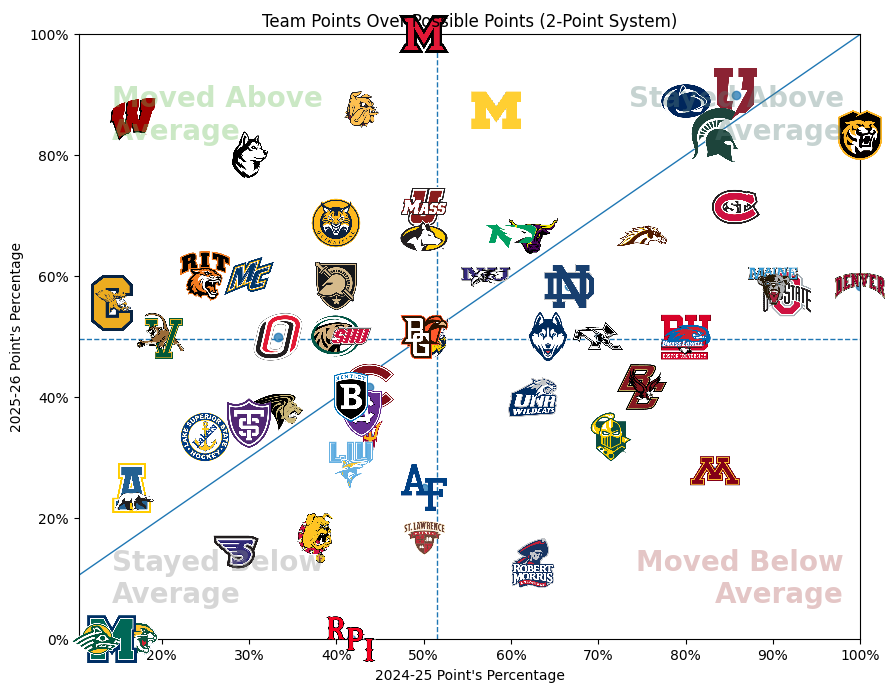

In [256]:
png_path = create_points_pct_scatter(
    df=comparison_df,
    year_one_name="2024-25",
    year_two_name="2025-26",
    point_system=2,  # <---- choose 2 or 3 pt system
    highlight_teams= teams_to_highlight,
    logo_mapping=logo_mapping,          # <-- pass it
    logo_folder=logo_folder   # <-- pass it (absolute path recommended)
)

